In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# ⛈ Bias Correction for GSMaP Using Rainfall Observations

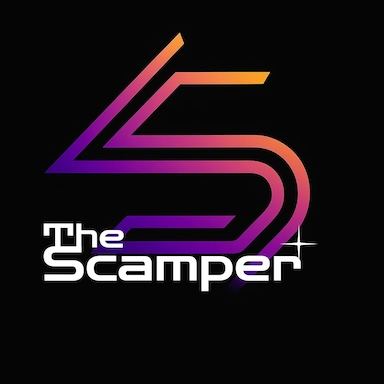

This notebook implements a **bias correction approach** for satellite-based rainfall estimates (GSMaP) using ground-based station observations.  
We focus on the 2015–2020 training period and aim to build a model that learns the **systematic difference (bias)** between GSMaP and actual rainfall.

---

## Dataset Overview

We use the following files from the `Train/` directory:

- `HII_station_2015-2020.csv`: Ground-based rainfall observations for 495 stations.
- `GSMap_now_station_2015-2020.csv`: GSMaP rainfall estimates for the same time period and locations.

Each file has the following format:

- **Rows:** Hourly time steps — `52608` hours from 2015 to 2020
- **Columns:** Station codes — `495` weather stations across Thailand
---

The cell below loads and previews the datasets.


In [2]:
import pandas as pd
import numpy as np

obs = pd.read_csv("Train/HII_station_2015-2020.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap = pd.read_csv("Train/GSMap_now_station_2015-2020.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap

,ACRU,BAKI,BARI,BBHN,BBON,BBUA,BBWN,BCNG,BDAR,BDCP,...,WTSG,YGHM,YOM001,YOM003,YOM005,YOM006,YOM007,YOM008,YOM009,YOM010
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.09,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
52604,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
52605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
52606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0


---

### 1. Skewed Rainfall Distributions and Log Transformation

Both **Rainfall Observations** and **GSMaP values** are highly right-skewed, with many zeros and a few extreme outliers.  
To stabilize variance and make the distribution more symmetric, we apply a log transformation:

$$
\text{log\_obs} = \log(1 + \text{Observation})
$$

$$
\text{log\_gsmap} = \log(1 + \text{GSMaP})
$$

Below, we visualize the effect of this transformation on the distribution of observation values and compute their skewness before and after log1p.

---


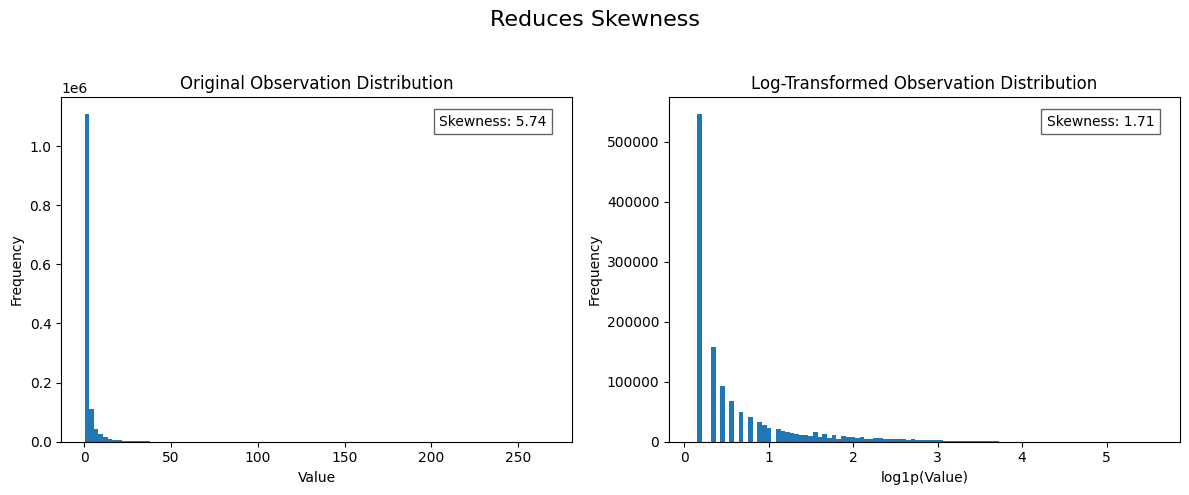

In [3]:
from scipy.stats import skew
import matplotlib.pyplot as plt

# Flatten and exclude zeros from Observation
target_flat = obs.to_numpy().flatten()
target_nonzero = target_flat[target_flat > 0]
target_log = np.log1p(target_nonzero)

# Compute skewness
skew_original = skew(target_nonzero)
skew_log = skew(target_log)

# Plot
plt.figure(figsize=(12, 5))
plt.suptitle("Reduces Skewness", fontsize=16)

# Original non-zero Observation distribution
plt.subplot(1, 2, 1)
plt.hist(target_nonzero, bins=100)
plt.title("Original Observation Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.text(
    0.95,
    0.95,
    f"Skewness: {skew_original:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6),
)

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(target_log, bins=100)
plt.title("Log-Transformed Observation Distribution")
plt.xlabel("log1p(Value)")
plt.ylabel("Frequency")
plt.text(
    0.95,
    0.95,
    f"Skewness: {skew_log:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.show()

---
### **2. Bias Computation**

* Instead of predicting log rainfall directly, we compute:

  $$
  \text{Bias} = \log(1 + \text{GSMaP}) - \log(1 + \text{Observation})
  $$
* This bias captures the **systematic deviation** of GSMaP from observations in log space.
---

### Visualize Log-Transformed Time Series and Bias

We plot the log-transformed precipitation from GSMaP and observations for a single station, and visualize their bias over time:


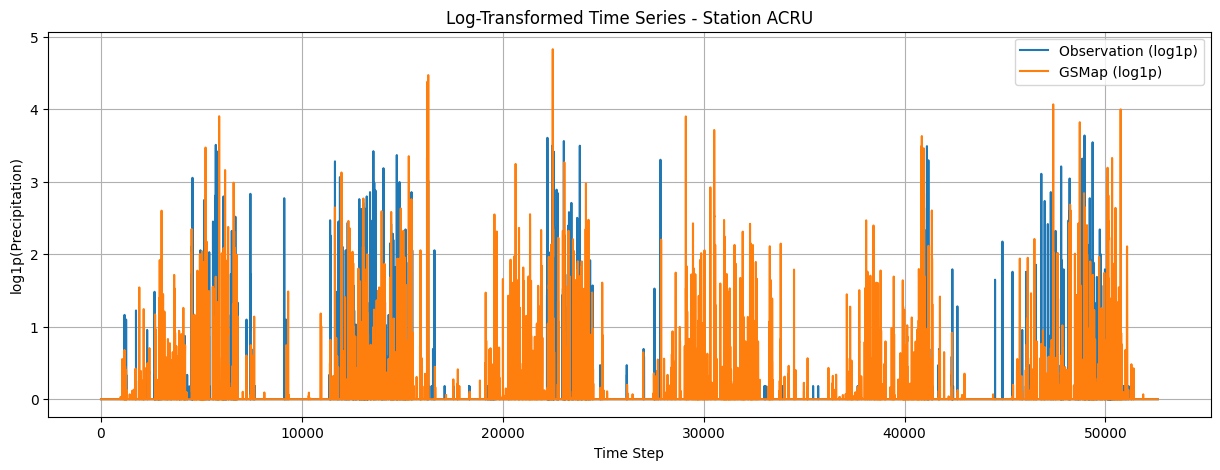

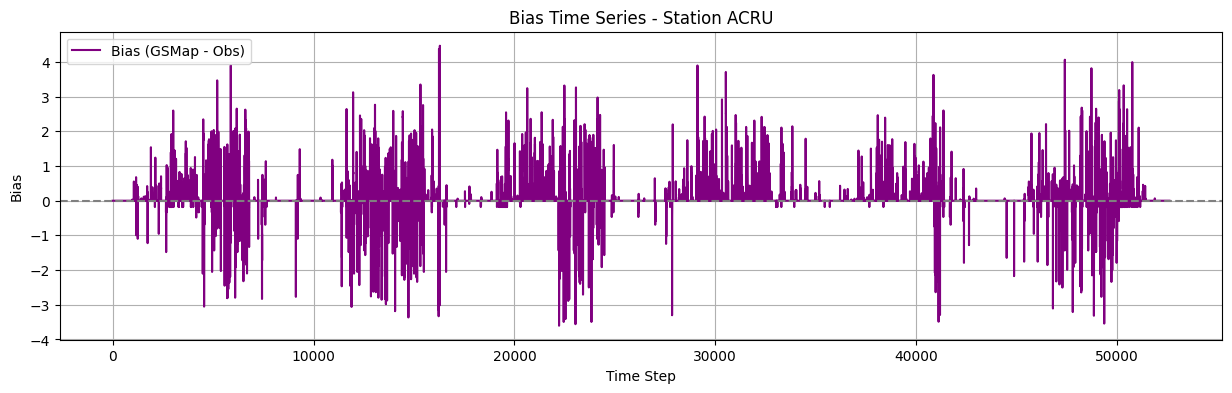

In [4]:
# Extract series
station = "ACRU"
obs_series = obs[station].values
gsmap_series = gsmap[station].values

# Apply log1p transformation
obs_log = np.log1p(obs_series)
gsmap_log = np.log1p(gsmap_series)

# Plot
plt.figure(figsize=(15, 5))
plt.plot(obs_log, label="Observation (log1p)")
plt.plot(gsmap_log, label="GSMap (log1p)")
plt.title(f"Log-Transformed Time Series - Station {station}")
plt.xlabel("Time Step")
plt.ylabel("log1p(Precipitation)")
plt.legend()
plt.grid(True)
plt.show()

# bias
bias = gsmap_log - obs_log

# Plot bias
plt.figure(figsize=(15, 4))
plt.plot(bias, label="Bias (GSMap - Obs)", color="purple")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Bias Time Series - Station ACRU")
plt.xlabel("Time Step")
plt.ylabel("Bias")
plt.legend()
plt.grid(True)
plt.show()

---

### 3. **Bias Prediction and Correction**

We'll train a model to predict the **log-space bias** between GSMaP and observations:

$$
\text{Bias} = \log(1 + \text{GSMaP}) - \log(1 + \text{Observation})
$$

This **residual learning** approach focuses on correcting GSMaP errors rather than predicting rainfall directly.

####  Model Input:
- Log-transformed GSMaP   
- Additional features, time (hour, day of year), spatial info, lagged values

####  Model Target:
$$
\text{Target} = \text{Bias}
$$

---

###  Bias Correction

Once we predict bias:

$$
\widehat{\text{Bias}} = f(\text{Features})
$$

we correct GSMaP as:

$$
\log(1 + \text{Corrected}) = \log(1 + \text{GSMaP}) - \widehat{\text{Bias}}
$$

and recover the final estimate:

$$
\text{Corrected} = \exp\left(\log(1 + \text{GSMaP}) - \widehat{\text{Bias}}\right) - 1
$$

This yields a GSMaP estimate corrected toward ground observations.

---


###  Prepare Target Output

We prepare the target for training by computing the log-space bias between GSMaP and observations:

$$
\text{Bias} = \log(1 + \text{GSMaP}) - \log(1 + \text{Observation})
$$

This bias matrix will serve as the target for our model, with shape:

$$
(52608 \text{ hours}, 495 \text{ stations})
$$


In [5]:
obs = pd.read_csv("Train/HII_station_2015-2020.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap = pd.read_csv("Train/GSMap_now_station_2015-2020.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)

# Apply log1p transformation
obs_log = np.log1p(obs.to_numpy())
gsmap_log = np.log1p(gsmap.to_numpy())
bias = gsmap_log - obs_log
print("Bias shape:", bias.shape)  # (52608, 495)

Bias shape: (52608, 495)


---

### 4. Model Approach: Multi-Station Joint Prediction

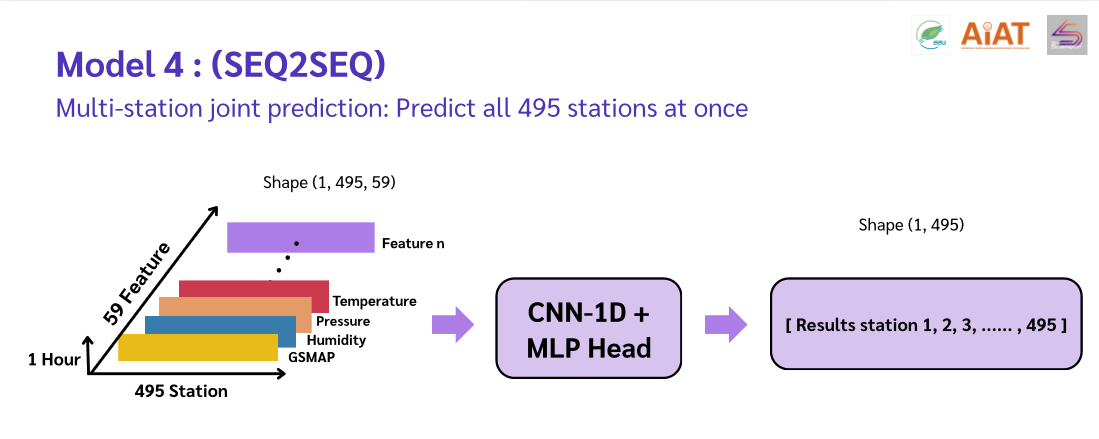

We'll use a **sequence-to-sequence (Seq2Seq)** model that predicts the log-space bias for **all 495 stations simultaneously** at each hourly time step.

This approach allows the model to learn **spatial and temporal dependencies** across stations and weather variables, leveraging cross-station correlation patterns.

#### Input and Output Structure
---

#### Input–Output Format

- **Input Shape**:  
  $$
  (1, 495, 59)
  $$
  Each sample represents one hour across 495 stations, with 59 features per station.

- **Output Shape**:  
  $$
  (1, 495)
  $$
  The model outputs the predicted log-bias for each of the 495 stations at that time step.

---

#### Feature Breakdown (59 features per station)

- **GSMaP** + 12-hour lag:
  - `GSMaP_t`, `GSMaP_{t-1}`, ..., `GSMaP_{t-12}` → 13 features

- **Humidity** + 12-hour lag:
  - `Humidity_t`, `Humidity_{t-1}`, ..., `Humidity_{t-12}` → 13 features

- **Pressure** + 12-hour lag:
  - `Pressure_t`, ..., `Pressure_{t-12}` → 13 features

- **Temperature** + 12-hour lag:
  - `Temp_t`, ..., `Temp_{t-12}` → 13 features

- **Time Encoding**:
  - `hour_sin`, `hour_cos`, `year_sin`, `year_cos` → 4 features

- **Station Metadata**:
  - `latitude`, `longitude`, `elevation` → 3 features

---

*This setup enables the model to learn **spatiotemporal patterns** and jointly calibrate GSMaP biases across all stations using shared context at each hour.*

---

### 5. Feature Preparation

We prepare 59 input features per station by applying clipping, normalization, and lag generation for each meteorological variable. These include:

- **Temperature**, **Humidity**, and **Pressure**:  
  Clipped and normalized, with 12-hour lag features.

- **GSMaP**:  
  Log-transformed using `log1p`, then 12 lag features are created.

These transformations help stabilize ranges and capture short-term temporal dynamics for each station.

---


In [6]:
# --- Temperature ---
temp_train = (
    pd.read_csv("Train/Temperature_2015-2020.csv")
    .drop(columns=["Year", "Month", "Day", "Hour"])
    .clip(lower=8, upper=50)
    / 50
)
temp_lags = {f"temp_train_{i}": temp_train.shift(i).fillna(0) for i in range(13)}

# --- Humidity ---
humd_train = (
    pd.read_csv("Train/Humidity_2015-2020.csv")
    .drop(columns=["Year", "Month", "Day", "Hour"])
    .clip(lower=10, upper=100)
    / 100
)
humd_lags = {f"humd_train_{i}": humd_train.shift(i).fillna(0) for i in range(13)}

# --- Pressure ---
pres_train = (
    pd.read_csv("Train/Pressure_2015-2020.csv")
    .drop(columns=["Year", "Month", "Day", "Hour"])
    .clip(lower=900, upper=1100)
    / 1100
)
pres_lags = {f"pres_train_{i}": pres_train.shift(i).fillna(0) for i in range(13)}

# --- GSMaP (Log-Transformed) ---
gsmap_raw = pd.read_csv("Train/GSMap_now_station_2015-2020.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap_train = np.log1p(gsmap_raw)
gsmap_lags = {
    f"gsmap_train_{i}": pd.DataFrame(gsmap_train).shift(i).fillna(0) for i in range(13)
}

# Preview one set of features
gsmap_lags["gsmap_train_12"]

,ACRU,BAKI,BARI,BBHN,BBON,BBUA,BBWN,BCNG,BDAR,BDCP,...,WTSG,YGHM,YOM001,YOM003,YOM005,YOM006,YOM007,YOM008,YOM009,YOM010
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52604,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

### Feature Stacking

After preprocessing and generating lag features, we now **stack all variables** across time for each of the 495 stations. This produces a 3D tensor with shape:

$$
(52608, 495, 52)
$$

Where:

* `52608` = hourly time steps (2015–2020)
* `495` = weather stations
* `52` = features (13 each from temperature, humidity, pressure, and GSMaP)

This tensor will be used as the **input** to our sequence model.

---

In [7]:
train_feat = np.stack(
    [temp_lags[f"temp_train_{i}"].to_numpy() for i in range(13)]
    + [humd_lags[f"humd_train_{i}"].to_numpy() for i in range(13)]
    + [pres_lags[f"pres_train_{i}"].to_numpy() for i in range(13)]
    + [gsmap_lags[f"gsmap_train_{i}"].to_numpy() for i in range(13)],
    axis=-1,
)

print("train_feat shape:", train_feat.shape)  # (52608, 495, 52)

train_feat shape: (52608, 495, 52)


---

### Static Features: Station Metadata

Each station has associated static metadata that doesn't change over time but can provide useful spatial context for the model:

* **Longitude**
* **Latitude**
* **Elevation**

We normalize each of these features to the $[0, 1]$ range using min–max scaling based on the dataset maximums.

These static features will be later concatenated to the dynamic features for each station.

---

In [8]:
static_features_df = pd.read_csv("Coor_HII_495Sta_Elevation.csv")
static_features_df = static_features_df.rename(columns={"STA": "item_id"})

# Normalize spatial features
to_normalize = ["long", "lat", "elevation"]
for feat in to_normalize:
    static_features_df[feat] = (
        static_features_df[feat] / static_features_df.describe()[feat]["max"]
    )

static_features_df

,item_id,long,lat,elevation
0,ACRU,0.991848,0.774020,0.180887
1,BAKI,0.980379,0.863725,0.198305
2,BARI,0.943318,0.739216,0.185713
3,BBHN,0.934408,0.467647,0.021772
4,BBON,0.943128,0.922549,0.455808
...,...,...,...,...
490,YOM006,0.946540,0.843137,0.070613
491,YOM007,0.947488,0.829902,0.056491
492,YOM008,0.949479,0.819118,0.034130
493,YOM009,0.950427,0.799510,0.032953


---

### Combine Static and Dynamic Features

To incorporate spatial metadata (**longitude**, **latitude**, **elevation**) into the training data:

* We **tile** the static features along the time dimension to align with the dynamic features:

  $$
  (52608, 495, 3)
  $$

* Then we **concatenate** them along the feature axis (last dimension), resulting in the final input tensor:

  $$
  \text{Final Shape} = (52608, 495, 55)
  $$

This setup allows the model to learn from both **dynamic weather patterns** and **station-specific characteristics**, enhancing its ability to correct GSMaP bias across space and time.

---


In [9]:
# Convert static features to NumPy (exclude 'item_id' column)
static_values = static_features_df[["long", "lat", "elevation"]].to_numpy()

# Repeat static features across all time steps
# Shape: (52608, 495, 3)
static_features_train = np.tile(
    static_values[np.newaxis, :, :], (train_feat.shape[0], 1, 1)
)

# Concatenate with dynamic features
train_feat = np.concatenate([train_feat, static_features_train], axis=-1)

print("train_feat shape:", train_feat.shape)  # Expected: (52608, 495, 55)

train_feat shape: (52608, 495, 55)


---

### Time Features: Hour and Day-of-Year Encoding

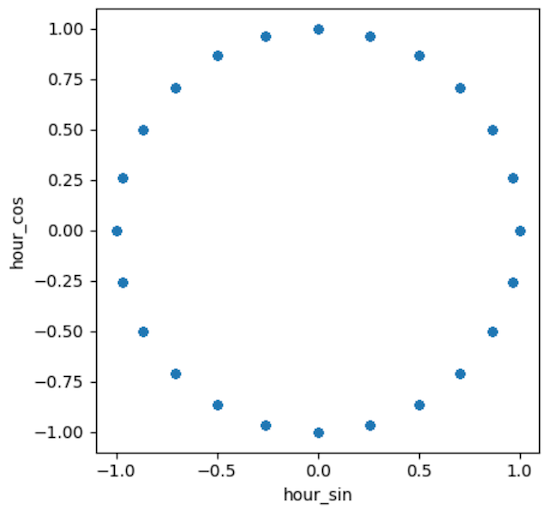

To help the model learn temporal patterns, we encode **cyclical time features** using sine and cosine transforms:

* **Hour of Day**:

  $$
  \text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{Hour}}{24}\right), \quad
  \text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{Hour}}{24}\right)
  $$

* **Day of Year**:

  $$
  \text{dayofyear\_sin} = \sin\left(\frac{2\pi \cdot \text{DayOfYear}}{365}\right), \quad
  \text{dayofyear\_cos} = \cos\left(\frac{2\pi \cdot \text{DayOfYear}}{365}\right)
  $$

This provides the model with smooth, periodic representations of time, capturing diurnal and seasonal effects without abrupt jumps.

---


In [10]:
time_feat = pd.read_csv("Train/HII_station_2015-2020.csv")[
    ["Year", "Month", "Day", "Hour"]
]
time_feat["datetime"] = pd.to_datetime(time_feat[["Year", "Month", "Day", "Hour"]])
time_feat["dayofyear"] = time_feat["datetime"].dt.dayofyear
time_feat

,Year,Month,Day,Hour,datetime,dayofyear
0,2015,1,1,0,2015-01-01 00:00:00,1
1,2015,1,1,1,2015-01-01 01:00:00,1
2,2015,1,1,2,2015-01-01 02:00:00,1
3,2015,1,1,3,2015-01-01 03:00:00,1
4,2015,1,1,4,2015-01-01 04:00:00,1
...,...,...,...,...,...,...
52603,2020,12,31,19,2020-12-31 19:00:00,366
52604,2020,12,31,20,2020-12-31 20:00:00,366
52605,2020,12,31,21,2020-12-31 21:00:00,366
52606,2020,12,31,22,2020-12-31 22:00:00,366


In [11]:
# Add cyclic encoding
time_feat["hour_sin"] = np.sin(2 * np.pi * time_feat["Hour"] / 24)
time_feat["hour_cos"] = np.cos(2 * np.pi * time_feat["Hour"] / 24)

time_feat["dayofyear_sin"] = np.sin(2 * np.pi * time_feat["dayofyear"] / 365)
time_feat["dayofyear_cos"] = np.cos(2 * np.pi * time_feat["dayofyear"] / 365)

time_feat = time_feat[["hour_sin", "hour_cos", "dayofyear_sin", "dayofyear_cos"]]
time_feat

,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,0.000000,1.000000,0.017213,0.999852
1,0.258819,0.965926,0.017213,0.999852
2,0.500000,0.866025,0.017213,0.999852
3,0.707107,0.707107,0.017213,0.999852
4,0.866025,0.500000,0.017213,0.999852
...,...,...,...,...
52603,-0.965926,0.258819,0.017213,0.999852
52604,-0.866025,0.500000,0.017213,0.999852
52605,-0.707107,0.707107,0.017213,0.999852
52606,-0.500000,0.866025,0.017213,0.999852


---

### Combine Time Features with Input Tensor

To finalize the model input, we incorporate the **cyclical time features** for each hourly timestamp:

* The time feature matrix has shape:

  $$
  (52608, 4)
  $$

* We **repeat** this across all stations (495) to match the dynamic feature tensor.

* Then, we **concatenate** along the last axis to create the final feature tensor:

  $$
  (52608, 495, 59)
  $$

This gives the model complete context at each step — weather history, spatial metadata, and time-aware encodings.

---


In [12]:
# Broadcast time features to all stations
time_feat_expanded = np.tile(
    time_feat.to_numpy()[:, np.newaxis, :], (1, train_feat.shape[1], 1)
)  # Shape: (52608, 495, 4)

# Concatenate along last dimension (features)
train_feat = np.concatenate([train_feat, time_feat_expanded], axis=-1)

# Final input shape
print("Final input shape:", train_feat.shape)  # (52608, 495, 59)

Final input shape: (52608, 495, 59)


---

### Test Set Preprocessing (2021–2024)

To evaluate the model, we preprocess the `Test/` set using the **same steps** as the training data:

* Clip and normalize temperature, humidity, and pressure
* Apply log-transform to GSMaP
* Generate 12-hour lag features
* Add static station metadata (latitude, longitude, elevation)
* Add cyclic time encodings (hour of day, day of year)

This ensures the model sees test data in the same shape and distribution as the training inputs:

$$
\text{{Final Shape}} = (\text{{test hours}}, 495, 59)
$$

---


In [13]:
# --- Load and process test weather features ---
def load_test_series(file, clip_min, clip_max, div):
    return (
        pd.read_csv(file)
        .drop(columns=["Year", "Month", "Day", "Hour"])
        .clip(lower=clip_min, upper=clip_max)
        / div
    )


temp_test = load_test_series("Test/Temperature_2021-2024.csv", 8, 50, 50)
humd_test = load_test_series("Test/Humidity_2021-2024.csv", 10, 100, 100)
pres_test = load_test_series("Test/Pressure_2021-2024.csv", 900, 1100, 1100)

gsmap_test_raw = pd.read_csv("Test/GSMap_now_station_2021-2024.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap_test = np.log1p(gsmap_test_raw)


# --- Generate lags (0 to 12) ---
def make_lags(df, prefix):
    return {f"{prefix}_{i}": df.shift(i).fillna(0) for i in range(13)}


temp_lags_test = make_lags(temp_test, "temp")
humd_lags_test = make_lags(humd_test, "humd")
pres_lags_test = make_lags(pres_test, "pres")
gsmap_lags_test = make_lags(pd.DataFrame(gsmap_test), "gsmap")

# --- Stack test dynamic features ---
test_feat = np.stack(
    [temp_lags_test[f"temp_{i}"].to_numpy() for i in range(13)]
    + [humd_lags_test[f"humd_{i}"].to_numpy() for i in range(13)]
    + [pres_lags_test[f"pres_{i}"].to_numpy() for i in range(13)]
    + [gsmap_lags_test[f"gsmap_{i}"].to_numpy() for i in range(13)],
    axis=-1,
)  # Shape: (N_test, 495, 52)

# --- Load and expand static metadata ---
static_df = pd.read_csv("Coor_HII_495Sta_Elevation.csv").rename(
    columns={"STA": "item_id"}
)
for feat in ["long", "lat", "elevation"]:
    static_df[feat] = static_df[feat] / static_df[feat].max()

static_feat = np.tile(
    static_df[["long", "lat", "elevation"]].to_numpy()[np.newaxis, :, :],
    (test_feat.shape[0], 1, 1),
)  # (N_test, 495, 3)

# --- Combine static + dynamic ---
test_feat = np.concatenate([test_feat, static_feat], axis=-1)  # (N_test, 495, 55)

# --- Create time features for test set ---
time_feat_test = pd.read_csv("Test/GSMap_now_station_2021-2024.csv")[
    ["Year", "Month", "Day", "Hour"]
]
time_feat_test["datetime"] = pd.to_datetime(
    time_feat_test[["Year", "Month", "Day", "Hour"]]
)
time_feat_test["dayofyear"] = time_feat_test["datetime"].dt.dayofyear

time_feat_test["hour_sin"] = np.sin(2 * np.pi * time_feat_test["Hour"] / 24)
time_feat_test["hour_cos"] = np.cos(2 * np.pi * time_feat_test["Hour"] / 24)
time_feat_test["dayofyear_sin"] = np.sin(2 * np.pi * time_feat_test["dayofyear"] / 365)
time_feat_test["dayofyear_cos"] = np.cos(2 * np.pi * time_feat_test["dayofyear"] / 365)

time_np_test = np.tile(
    time_feat_test[
        ["hour_sin", "hour_cos", "dayofyear_sin", "dayofyear_cos"]
    ].to_numpy()[:, np.newaxis, :],
    (1, test_feat.shape[1], 1),
)  # (N_test, 495, 4)

# --- Final test input ---
test_feat = np.concatenate([test_feat, time_np_test], axis=-1)  # (N_test, 495, 59)
print("Test feature shape:", test_feat.shape)

Test feature shape: (35064, 495, 59)


---

### Save Preprocessed Data (Optional)

To avoid re-running the entire preprocessing pipeline every time, we can save the processed arrays to `.npy` files:

* `train.npy`: Full input feature tensor for training (shape: 52608 × 495 × 59)
* `target.npy`: Log-bias target tensor for training (shape: 52608 × 495)
* `test.npy`: Full input feature tensor for test set (shape: test\_hours × 495 × 59)

These can later be loaded using `np.load(...)`.

---

In [14]:
# Optional: Save processed arrays
np.save("train.npy", train_feat)  # Input features for training
np.save("target.npy", bias)  # Log-bias target
np.save("test.npy", test_feat)  # Input features for test data

---

### 6. Model Architecture: Multi-Station CNN Bias Predictor

We define a **multi-layer convolutional neural network (CNN)** model to jointly predict **log-space bias** across **495 stations** at each hourly time step.

---

#### Key Architectural Highlights

* **1D Convolutions Across Stations**
  Each input is shaped `(495 stations, 59 features)`.
  The model applies **1D convolutions** across the station axis to capture **spatial relationships** among nearby stations at the same time step.

* **Deep CNN Feature Extractor**
  The model stacks **5 convolutional blocks**, each using:

  * **He Normal initializer** for better weight scaling
  * **Batch Normalization** for stable training
  * **GELU activation** for smooth non-linearity

* **Station-wise Dense Refinement**
  After spatial feature extraction:

  * A **layer-normalized** dense block is applied per station, repeated **3 times**
  * Each block includes: `Dense → LayerNorm → GELU → Dropout`
  * This allows station-specific calibration of deep features

* **Output Layer**

  * Final dense layer with 1 output per station
  * Output is reshaped to `(batch_size, 495)` for log-bias prediction at all stations

---

#### Model Output Shape

$$
\text{Output shape: (batch\_size, 495)}
$$

Each output corresponds to the **predicted log-bias** at a specific hour for all 495 stations.

---

This CNN-based model efficiently captures both **global spatial dependencies** and **local station-level patterns**, making it well-suited for **nationwide rainfall bias correction**.


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers, initializers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW

# Show GPUs and enable memory growth
gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible to TensorFlow:", gpus)
if len(gpus) < 1:
    raise RuntimeError("No GPUs detected! Check CUDA / drivers.")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Optional speedups
tf.keras.mixed_precision.set_global_policy("mixed_float16")  # FP16
tf.config.optimizer.set_jit(True)  # XLA

tf.keras.backend.clear_session()


# ──────────────────────────────
# Helper: Conv → BN → GELU
# ──────────────────────────────
def conv_block(x, filters, k, name):
    x = layers.Conv1D(
        filters,
        k,
        padding="same",
        use_bias=False,
        kernel_initializer=initializers.HeNormal(),
        name=f"{name}_conv",
    )(x)

    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("gelu", name=f"{name}_gelu")(x)
    return x


# ──────────────────────────────
# Model
# ──────────────────────────────
def build_rainfall_model(l2_weight=1e-3, dropout_rate=0.3):
    inputs = Input(shape=(495, 59))

    # -------- CNN feature extractor --------
    x = conv_block(inputs, 64, 5, "cnn1")
    x = conv_block(x, 128, 5, "cnn2")
    x = conv_block(x, 256, 5, "cnn3")
    x = conv_block(x, 512, 5, "cnn4")
    x = conv_block(x, 1024, 5, "cnn5")

    # -------- Per-station dense head --------
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    for i in range(3):
        x = layers.Dense(
            512,
            activation=None,
            kernel_initializer=initializers.HeNormal(),
            kernel_regularizer=regularizers.l2(l2_weight),
            name=f"dense{i+1}",
        )(x)
        x = layers.LayerNormalization(epsilon=1e-6, name=f"ln{i+1}")(x)
        x = layers.Activation("gelu", name=f"gelu{i+1}")(x)
        x = layers.Dropout(dropout_rate, name=f"dropout{i+1}")(x)
        
    # -------- Output --------
    out = layers.Dense(
        1,
        dtype="float32",
        kernel_initializer=initializers.HeNormal(),
        kernel_regularizer=regularizers.l2(l2_weight),
        name="out",
    )(x)
    out = layers.Reshape((495,), name="out_reshape")(out)

    return models.Model(inputs, out, name="SimpleRainfallModel")

E0000 00:00:1750239411.018127 1777203 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750239411.021498 1777203 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750239411.032522 1777203 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750239411.032530 1777203 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750239411.032532 1777203 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750239411.032533 1777203 computation_placer.cc:177] computation placer already registered. Please check linka

GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

### Model Compilation and Training Setup

We now configure training callbacks and compile the model with appropriate loss, optimizer, and evaluation metrics:

#### Callbacks Used:

* **ModelCheckpoint**: Saves the best model based on validation loss.
* **EarlyStopping**: Stops training if validation loss does not improve for 50 epochs.
* **ReduceLROnPlateau**: Reduces the learning rate when the validation loss plateaus.

#### Optimization Settings:

* **Optimizer**: `AdamW` with learning rate = 1e-3 and weight decay = 1e-6.
* **Loss Function**: `Mean Squared Error (MSE)` — ideal for log-space regression.
* **Metric**: `Mean Absolute Error (MAE)` — for interpretability in log-bias units.

We then compile the model and print a summary of all layers and parameters.

---


In [16]:
# ──────────────────────────────
# Callbacks
# ──────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath="rainfall_checkpoint/rainfall_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.95,
    patience=1,
    min_lr=1e-9,
    verbose=1,
)

# ──────────────────────────────
# Build and Compile
# ──────────────────────────────
model = build_rainfall_model()
# model.load_weights("rainfall_checkpoint/rainfall_best_model.keras") #For continue training

optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-6)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
model.summary()

I0000 00:00:1750239414.135119 1777203 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38484 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


Model: "SimpleRainfallModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 495, 59)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn1_conv (Conv1D)              │ (None, 495, 64)        │        18,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn1_bn (BatchNormalization)    │ (None, 495, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn1_gelu (Activation)          │ (None, 495, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn2_conv (Conv1D)              │ (None, 495, 128)       │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn2_bn (BatchNormalization)    │ (None, 495, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn2_gelu (Activation)          │ (None, 495, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn3_conv (Conv1D)              │ (None, 495, 256)       │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn3_bn (BatchNormalization)    │ (None, 495, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn3_gelu (Activation)          │ (None, 495, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn4_conv (Conv1D)              │ (None, 495, 512)       │       655,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn4_bn (BatchNormalization)    │ (None, 495, 512)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn4_gelu (Activation)          │ (None, 495, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn5_conv (Conv1D)              │ (None, 495, 1024)      │     2,621,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn5_bn (BatchNormalization)    │ (None, 495, 1024)      │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn5_gelu (Activation)          │ (None, 495, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 495, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 495, 512)       │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln1 (LayerNormalization)        │ (None, 495, 512)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gelu1 (Activation)              │ (None, 495, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 495, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 495, 512)       │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln2 (LayerNormalization)        │ (None, 495, 512)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gelu2 (Activation)              │ (None, 495, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,564,161 (17.41 MB)

 Trainable params: 4,560,193 (17.40 MB)

 Non-trainable params: 3,968 (15.50 KB)

---

### Visualize Model Architecture

To understand the structure of the CNN-based multi-station rainfall model, we use Keras's `plot_model` utility to display the model architecture with:

* **Layer names**
* **Input/output shapes**
* **Activation functions**

---


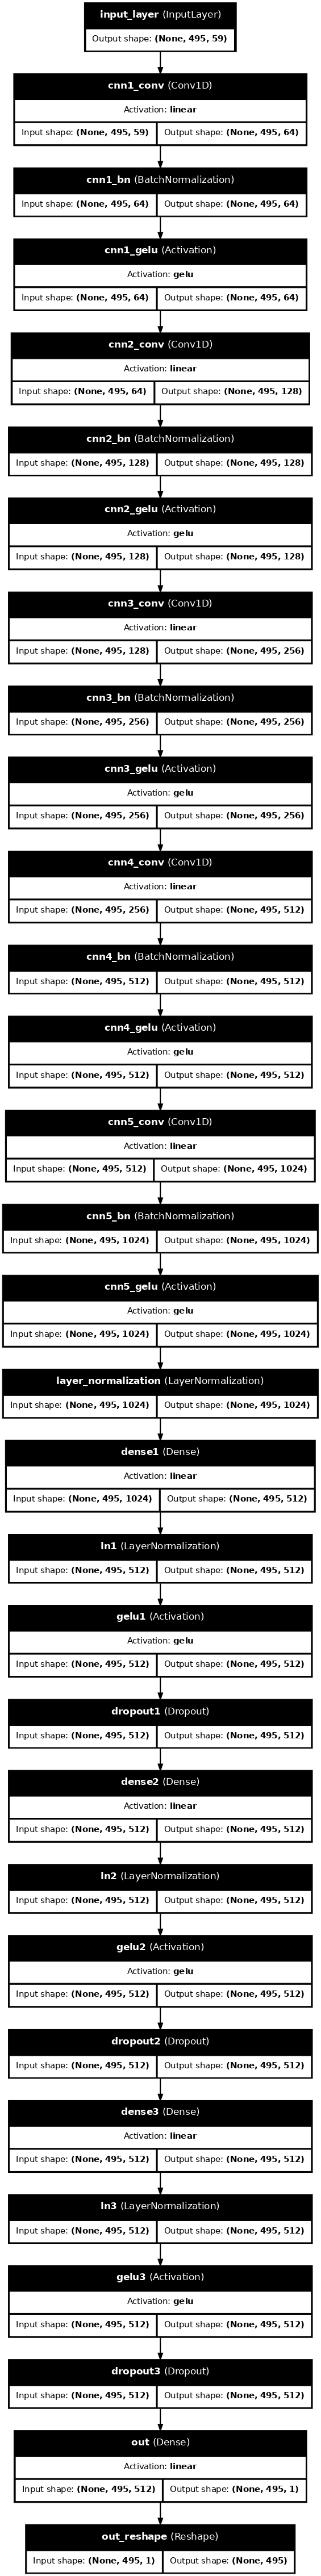

In [17]:
from tensorflow.keras.utils import plot_model

plot_model(
    model, show_layer_names=True, show_shapes=True, show_layer_activations=True, dpi=75
)

---

### Train the Bias Correction Model

We now train our model to learn the log-space bias between GSMaP and ground observations using the full dataset.

* **Loss**: Mean Squared Error (MSE)
* **Optimizer**: AdamW with learning rate scheduling and early stopping
* **Batch Size**: 2048
* **Epochs**: 1000

---


In [17]:
epochs = 1000
batch_size = 2048

history = model.fit(
    train_feat,
    bias,  # log-space bias target
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
)

Epoch 1/1000


I0000 00:00:1750239420.532561 1789622 service.cc:152] XLA service 0x7f1368004b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750239420.532589 1789622 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1750239420.544150 1789622 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750239420.611556 1789622 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 3.9303 - mae: 0.7052   
Epoch 1: val_loss improved from inf to 3.16209, saving model to rainfall_checkpoint/rainfall_best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - loss: 3.9127 - mae: 0.6969 - val_loss: 3.1621 - val_mae: 0.4271 - learning_rate: 0.0010
Epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - loss: 2.9876 - mae: 0.2699
Epoch 2: val_loss did not improve from 3.16209

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0009500000451225787.
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 671ms/step - loss: 2.9839 - mae: 0.2689 - val_loss: 3.1690 - val_mae: 0.6492 - learning_rate: 0.0010
Epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - loss: 2.6404 - mae: 0.2025
Epoch 3: val_loss improved from 3.16209 to 2.46061, saving model to rainfall_checkpoint/rainfall_best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 686ms/step - loss: 2.6371 - mae: 0.2022 - val_loss: 2.4606 - val_mae: 0.2326 - learning_rate: 9.5000e-04
Epoch 4/1000
21/21

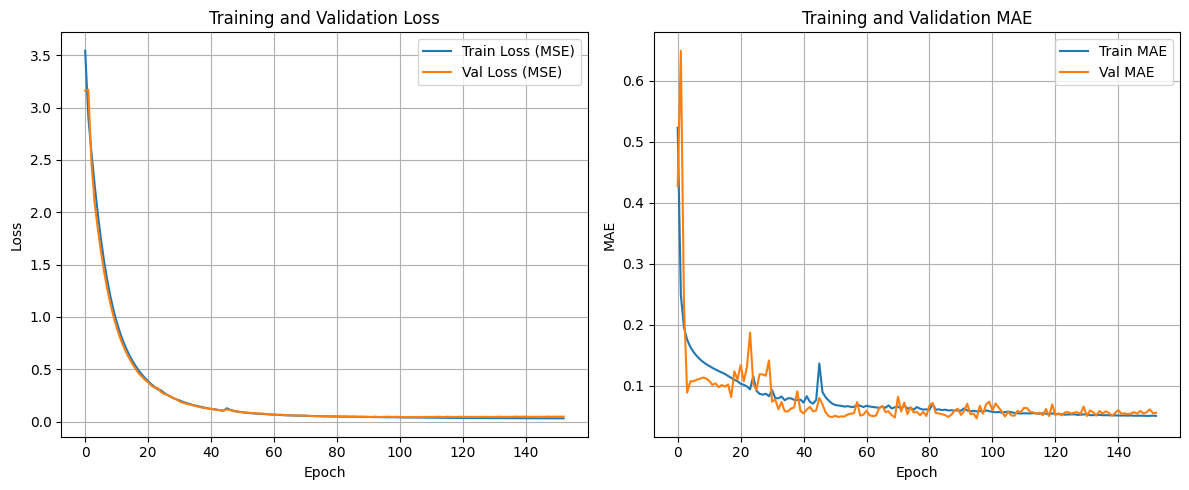

In [18]:
# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss (MSE)")
plt.plot(history.history["val_loss"], label="Val Loss (MSE)")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---

### Final Refit on Full Training Data

After validation-based training, we can optionally **refit the model** on the entire dataset to improve performance by exposing the model to **100% of the data**.

We keep the learning rate small and only train for a few epochs to avoid overfitting.

---

In [19]:
# Load the best checkpoint before refitting
model.load_weights("rainfall_checkpoint/rainfall_best_model.keras")

# Reduce learning rate for fine-tuning
model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-6), loss="mse", metrics=["mae"]
)

# Fine-tune on full training set for a few epochs
model.fit(
    train_feat,
    bias,  # Full target set
    epochs=10,
    batch_size=2048,
    verbose=1,
)

model.save("rainfall_checkpoint/final.keras")

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - loss: 0.0443 - mae: 0.0748
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0404 - mae: 0.0552
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0395 - mae: 0.0541
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0391 - mae: 0.0544
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0385 - mae: 0.0549
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 630ms/step - loss: 0.0379 - mae: 0.0546
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0371 - mae: 0.0538
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0369 - mae: 0.0538
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - loss: 0.0364 - mae: 0.0537
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 635ms/step - loss: 0.0356 - mae: 0.0535


---

### Predict on Test Set and Save Submission

We now use the trained model to predict rainfall for the test period. Predictions are in **log-space bias**, so we apply the correction formula:

$$
\text{Corrected GSMaP} = \exp\left(\log(1 + \text{GSMaP}) - \widehat{\text{Bias}}\right) - 1
$$

Finally, we post-process and save to submission format.

---


In [21]:
# Load final weights before predicting
model.load_weights("rainfall_checkpoint/final.keras")

# Predict log-space bias
pred_bias = model.predict(test_feat, batch_size=2048)

# Load raw GSMaP test values
gsmap_test_raw = pd.read_csv("Test/GSMap_now_station_2021-2024.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)
gsmap_test_log = np.log1p(gsmap_test_raw.to_numpy())  # log(1 + GSMaP)

# Apply correction: log(1 + corrected) = log(1 + GSMaP) - predicted bias
log_corrected = gsmap_test_log - pred_bias
corrected = np.expm1(log_corrected)  # inverse of log1p

# Clip tiny negatives (due to numerical errors) to zero
corrected = np.where(corrected < 0.1, 0, corrected)

# Fill into submission format
submission = pd.read_csv("sample_submission.csv")
submission.loc[:, "ACRU":] = corrected
submission.to_parquet("submission.parquet", index=False)
submission.head()

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step


,index,Year,Month,Day,Hour,ACRU,BAKI,BARI,BBHN,BBON,...,WTSG,YGHM,YOM001,YOM003,YOM005,YOM006,YOM007,YOM008,YOM009,YOM010
0,2021-1-1-0,2021,1,1,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-1-1-1,2021,1,1,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-1-1-2,2021,1,1,2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-1-1-3,2021,1,1,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-1-1-4,2021,1,1,4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



---

### Visualize Corrected GSMaP vs Original GSMaP

We compare the **bias-corrected GSMaP** predictions to the original raw GSMaP values for specific stations. This helps validate the correction effect.

---

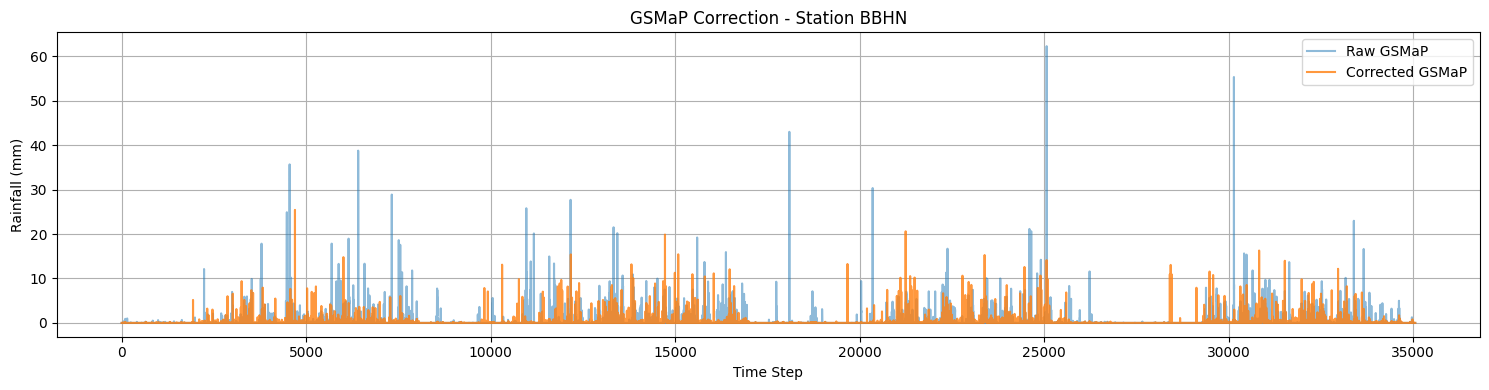

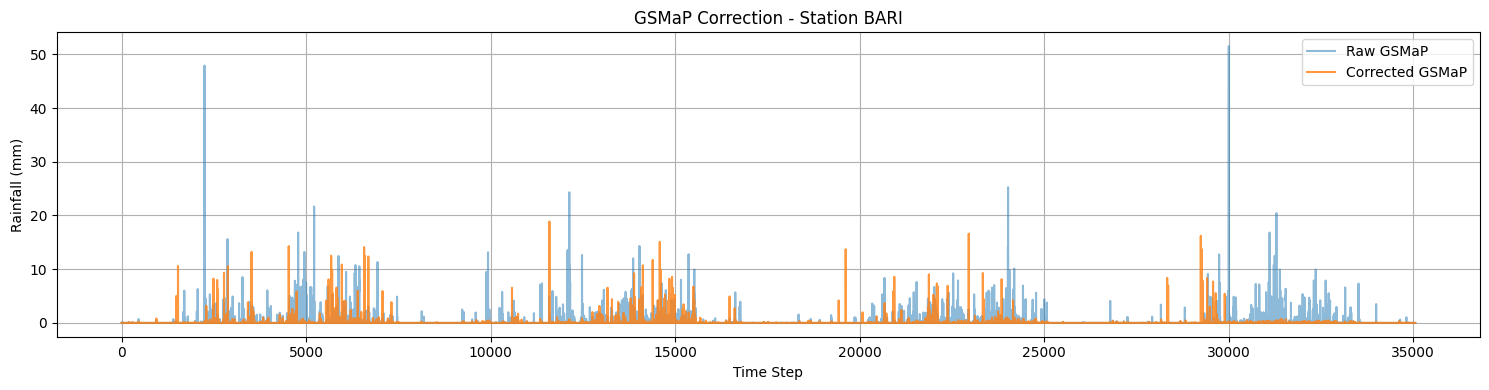

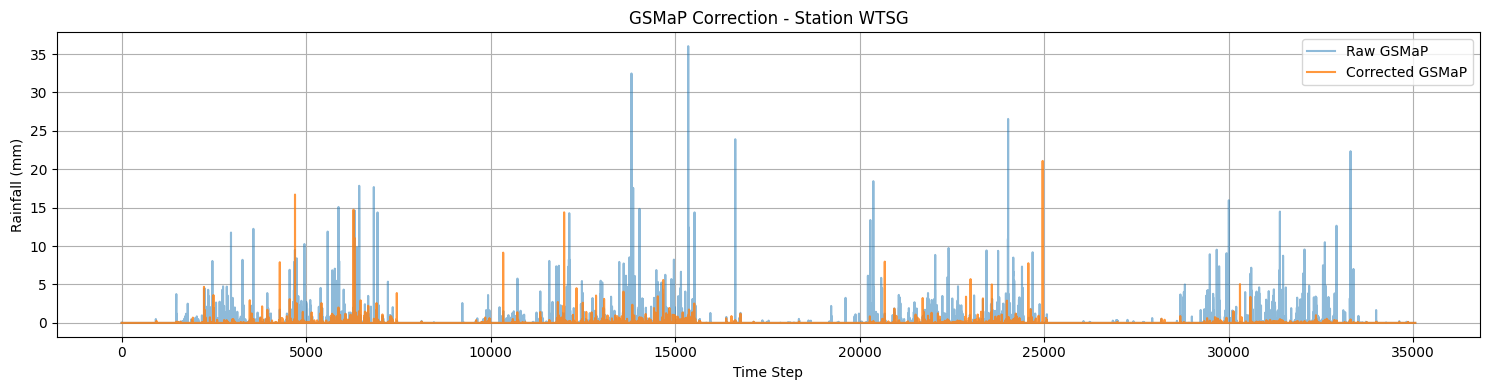

In [22]:
# Choose station(s) to visualize
stations_to_plot = ["BBHN", "BARI", "WTSG"]

# Load original GSMaP test series
raw_test = pd.read_csv("Test/GSMap_now_station_2021-2024.csv").drop(
    columns=["Year", "Month", "Day", "Hour"]
)

# Create time axis
time_axis = range(len(raw_test))

# Plot comparison
for station in stations_to_plot:
    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, raw_test[station], label="Raw GSMaP", alpha=0.5)
    plt.plot(
        time_axis,
        corrected[:, raw_test.columns.get_loc(station)],
        label="Corrected GSMaP",
        alpha=0.8,
    )
    plt.title(f"GSMaP Correction - Station {station}")
    plt.xlabel("Time Step")
    plt.ylabel("Rainfall (mm)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

---

## Summary and Takeaways

In this notebook, we implemented a **bias correction pipeline** for satellite-based rainfall estimates (GSMaP) using station-level ground truth from 495 weather stations across Thailand.

---

### Problem Framing

* Satellite rainfall data (GSMaP) is often **biased** compared to ground truth due to terrain, sensor limitations, and retrieval errors.
* Instead of predicting rainfall directly, we modeled the **log-space bias** between GSMaP and observed data:

  $$
  \text{Bias} = \log(1 + \text{GSMaP}) - \log(1 + \text{Obs})
  $$

---

### Why Log Transformation + MSE?

Rainfall data is **highly skewed**, with many zeros and a few extreme values (outliers).
To stabilize this:

* **Log Transformation** (`log1p`) compresses the scale of large rainfall values, reduces variance, and makes the distribution more symmetric.
* **Mean Squared Error (MSE)** in log space penalizes large deviations proportionally, encouraging the model to focus on both frequent small events and rare large ones.

> If we had used **MAE** on raw rainfall, the model would underfit rare heavy rainfall due to the overwhelming number of zero/light rain cases.
> Log + MSE allows more **balanced learning** across the full range of rainfall intensities.

---

###  Model Highlights

* Built a **Multi-Station CNN model** with:

  * Temporal lags (past 12 hours of rainfall and weather)
  * Cyclical time features (hour of day, day of year)
  * Static station metadata (longitude, latitude, elevation)
* Predicts log-bias across **all 495 stations** at once using convolution over the station axis.

---

### Training Strategy

* Used **log-transform + MSE loss** to handle skewed rainfall distributions.
* Applied **early stopping**, **learning rate scheduling**, and **model checkpointing** for robust training.
* Optionally **refined on full data** after validation-based training.

---

### Correction and Submission

* Applied predicted bias to correct GSMaP values:

  $$
  \text{Corrected GSMaP} = \exp\left(\log(1 + \text{GSMaP}) - \widehat{\text{Bias}}\right) - 1
  $$

* Saved corrected predictions in the required submission format (`.parquet`).

* Visualized original vs. corrected series for qualitative validation.

---

### Potential Improvements

* Incorporate **spatial graph structure** (e.g., GNNs) to model spatial dependencies more explicitly.
* Use **attention mechanisms** to dynamically weigh lag importance.
* Explore **ensemble models** for further robustness.

---

### Conclusion

This approach demonstrates how deep learning can be used to **calibrate satellite estimates** toward reliable ground observations.
By using **log transformation and MSE loss**, we overcame the challenges of skewed rainfall data and trained a model that generalizes across time and space for rainfall bias correction.

---
